# Machine Learning Modeling

In [ ]:
# Make sure you are at the parent directory
from pathlib import Path
import sys

# Define MODE
MODE = "COLAB" # Either "COLAB", "LOCAL", "EXPANSE"
if MODE.upper() not in ('EXPANSE', 'COLAB', 'LOCAL'):
    raise Exception("Invalid mode, the only acceptible are 'EXPANSE', 'COLAB', 'LOCAL'")
if MODE.upper() == "COLAB":
    from google.colab import drive
    drive.mount('/content/drive')

# Root path by MODE
PROJECT_ROOT_BY_MODE = {
    "COLAB": Path("/content/drive/MyDrive/DSC 288R/Project"),
    "EXPANSE": Path("/home/bguo3/bguo3/DSC-288R-Capstone-Final-Project"),
    "LOCAL": Path("/Users/steveg/Desktop/DSC-288R-Capstone-Final-Project"),
}
ROOT = PROJECT_ROOT_BY_MODE[MODE.upper()]

# Add the root path to global system
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

# Print the root path
print("MODE:", MODE)
print("PROJECT_ROOT:", ROOT)

Mounted at /content/drive
MODE: COLAB
PROJECT_ROOT: /content/drive/MyDrive/DSC 288R/Project


## Import Modules

In [ ]:
from pyspark.sql import functions as F

from src.utils.pyspark_utils import create_spark_session, memory_count
from src.utils.paths_utils import ProjectPaths
from src.utils.io_utils import read_spark_parquet
import src.pipelines.ML_modeling as ml

import time

## Read Train/Validation/Test Full/Sampled Dataset From Parquet

In [ ]:
# Set up for Spark app & resource allocation
spark = create_spark_session("steam_reviews_machine_learning_modeling")

# Load data
paths = ProjectPaths(MODE)
if MODE.upper() == "EXPANSE":
    train = read_spark_parquet(spark=spark, path=paths.random_row_train_parquet)
    val = read_spark_parquet(spark=spark, path=paths.random_row_val_parquet)
    test = read_spark_parquet(spark=spark, path=paths.random_row_test_parquet)
else:
    train = read_spark_parquet(spark=spark, path=paths.random_row_train_sampled_parquet)
    val = read_spark_parquet(spark=spark, path=paths.random_row_val_sampled_parquet)
    test = read_spark_parquet(spark=spark, path=paths.random_row_test_sampled_parquet)

Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/splits/random_row/train_sampled.parquet
Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/splits/random_row/val_sampled.parquet
Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/splits/random_row/test_sampled.parquet


In [ ]:
# Quick Feat Engineering here

from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from src.utils.paths_utils import ProjectPaths
from src.utils.io_utils import read_spark_parquet

# Re-load original train and validation datasets to ensure correct schema for feat_label
# This prevents errors if the cell is run multiple times after initial transformation
paths = ProjectPaths(MODE)
if MODE.upper() == "EXPANSE":
    train_df_initial = read_spark_parquet(spark=spark, path=paths.random_row_train_parquet)
    val_df_initial = read_spark_parquet(spark=spark, path=paths.random_row_val_parquet)
else:
    train_df_initial = read_spark_parquet(spark=spark, path=paths.random_row_train_sampled_parquet)
    val_df_initial = read_spark_parquet(spark=spark, path=paths.random_row_val_sampled_parquet)

def feat_label(df):
    feature_cols = [
        "author_num_games_owned",
        "author_num_reviews",
        "author_playtime_forever",
        "author_playtime_at_review",
        # "author_last_played",
        "voted_up",
        "votes_up",
        "votes_funny",
        "weighted_vote_score",
        "comment_count",
        "written_during_early_access",
        # "timestamp_created",
        # "timestamp_updated",
    ]

    feat_df = (
        df
        .withColumn('churn',
            F.when(F.col('author_playtime_last_two_weeks') > 60, 0)
            .otherwise(1)
        )
        .select(feature_cols + ['churn'])
    )

    print(f"Churn distribution for current DataFrame input to feat_label:")
    feat_df.groupBy('churn').count().show()

    feat_df.printSchema()

    final_df = (
        VectorAssembler(inputCols=feature_cols, outputCol='finalized_features')
        .transform(feat_df)
        .select('finalized_features', 'churn')
    )
    memory_count(final_df, include_row_count=True)

    return final_df

train = train_df_initial.transform(feat_label)
val = val_df_initial.transform(feat_label)

# # Analyze churn distribution in validation set and apply filtering if '1' is dominant
# val_churn_distribution = val.groupBy('churn').count().collect()
# churn_counts = {row['churn']: row['count'] for row in val_churn_distribution}

# churn_0_count = churn_counts.get(0, 0)
# churn_1_count = churn_counts.get(1, 0)

# print(f"Validation DataFrame churn distribution (after feat_label):")
# print(f"Churn 0 count: {churn_0_count}")
# print(f"Churn 1 count: {churn_1_count}")

# if churn_1_count > churn_0_count:
#     print("Churn '1' is dominant. Filtering out instances where churn == 1 from validation DataFrame.")
#     val = val.filter(F.col('churn') == 0)
# elif churn_1_count < churn_0_count:
#     print("Churn '0' is dominant. Filtering out instances where churn == 0 from validation DataFrame.")
#     val = val.filter(F.col('churn') == 1)
# else:
#     print("Churn '0' is dominant or counts are equal. No filtering applied to validation DataFrame based on dominance.")

# memory_count(val, include_row_count=True)
# print("Final validation DataFrame schema after potential filtering:")
# val.printSchema()

Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/splits/random_row/train_sampled.parquet
Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/splits/random_row/val_sampled.parquet
Churn distribution for current DataFrame input to feat_label:
+-----+-------+
|churn|  count|
+-----+-------+
|    1|1373537|
|    0|  99535|
+-----+-------+

root
 |-- author_num_games_owned: integer (nullable = true)
 |-- author_num_reviews: integer (nullable = true)
 |-- author_playtime_forever: integer (nullable = true)
 |-- author_playtime_at_review: integer (nullable = true)
 |-- voted_up: boolean (nullable = true)
 |-- votes_up: integer (nullable = true)
 |-- votes_funny: long (nullable = true)
 |-- weighted_vote_score: float (nullable = true)
 |-- comment_count: integer (nullable = true)
 |-- written_during_early_access: boolean (nullable = true)
 |-- churn: integer (nullable = false)

Total row counts: 1473072 rows
Total estimated size: 0.08 GB
Churn distribution

## Logistic Regression Model

In [ ]:
start = time.time()

lr, lr_train_pred, lr_val_pred = ml.fit_transform_model(
    model_name ='log_reg',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = True
)
ml.evaluate_model(
    model_name = 'log_reg',
    train_pred_df = lr_train_pred,
    test_pred_df = lr_val_pred,
    verbose = True
)

elapsed = time.time() - start
print(f"ML Logistic Regression took: {elapsed:.2f} seconds")

total_cores has 8
log_reg Train areaUnderROC: 0.8255
log_reg Test areaUnderROC: 0.8257

log_reg Train areaUnderPR: 0.9809
log_reg Test areaUnderPR: 0.9811

log_reg Train f1: 0.9113
log_reg Test f1: 0.9114

log_reg Train weightedPrecision: 0.9109
log_reg Test weightedPrecision: 0.9106

log_reg Train weightedRecall: 0.9333
log_reg Test weightedRecall: 0.9333

log_reg Train accuracy: 0.9333
log_reg Test accuracy: 0.9333

ML Logistic Regression took: 128.87 seconds


## Decision Tree Model

In [ ]:
start = time.time()

dt, dt_train_pred, dt_val_pred = ml.fit_transform_model(
    model_name ='decision_tree',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "decision_tree",
    train_pred_df= lr_train_pred,
    test_pred_df= lr_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Decision Tree took: {elapsed:.2f} seconds")

total_cores has 8
decision_tree Train areaUnderROC: 0.8255
decision_tree Test areaUnderROC: 0.8257

decision_tree Train areaUnderPR: 0.9809
decision_tree Test areaUnderPR: 0.9811

decision_tree Train f1: 0.9113
decision_tree Test f1: 0.9114

decision_tree Train weightedPrecision: 0.9109
decision_tree Test weightedPrecision: 0.9106

decision_tree Train weightedRecall: 0.9333
decision_tree Test weightedRecall: 0.9333

decision_tree Train accuracy: 0.9333
decision_tree Test accuracy: 0.9333

ML Decision Tree took: 101.28 seconds


## Random Forest

In [ ]:
start = time.time()

rf, rf_train_pred, rf_val_pred = ml.fit_transform_model(
    model_name ='random_forest',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "random_forest",
    train_pred_df= rf_train_pred,
    test_pred_df= rf_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Random Forest took: {elapsed:.2f} seconds")

total_cores has 8
random_forest Train areaUnderROC: 0.8543
random_forest Test areaUnderROC: 0.8521

random_forest Train areaUnderPR: 0.9860
random_forest Test areaUnderPR: 0.9857

random_forest Train f1: 0.8998
random_forest Test f1: 0.9003

random_forest Train weightedPrecision: 0.9257
random_forest Test weightedPrecision: 0.8700

random_forest Train weightedRecall: 0.9324
random_forest Test weightedRecall: 0.9327

random_forest Train accuracy: 0.9324
random_forest Test accuracy: 0.9327

ML Random Forest took: 254.77 seconds


## Support Vector Machine Model

In [ ]:
start = time.time()

svm, svm_train_pred, svm_val_pred = ml.fit_transform_model(
    model_name ='svm',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "svm",
    train_pred_df= svm_train_pred,
    test_pred_df= svm_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Support Vector Classifier took: {elapsed:.2f} seconds")

total_cores has 8
svm Train areaUnderROC: 0.7548
svm Test areaUnderROC: 0.7533

svm Train areaUnderPR: 0.9715
svm Test areaUnderPR: 0.9715

svm Train f1: 0.8998
svm Test f1: 0.9003

svm Train weightedPrecision: 0.8694
svm Test weightedPrecision: 0.8700

svm Train weightedRecall: 0.9324
svm Test weightedRecall: 0.9327

svm Train accuracy: 0.9324
svm Test accuracy: 0.9327

ML Support Vector Classifier took: 116.30 seconds


## Extra-Gradient Boost Model

In [ ]:
start = time.time()

# Temp preprocess data to avoid XGBoost error for N class expecting class value starting at 0
xgb_train_final = train.withColumn("churn", F.col("churn").cast("int"))
xgb_val_final = val.withColumn("churn", F.col("churn").cast("int"))

xgb, xgb_train_pred, xgb_val_pred = ml.fit_transform_model(
    model_name ='xgb',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    mode = MODE
)
ml.evaluate_model(
    model_name= "xgb",
    train_pred_df= xgb_train_pred,
    test_pred_df= xgb_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML XGBoost took: {elapsed:.2f} seconds")

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


xgb Train areaUnderROC: 0.8802
xgb Test areaUnderROC: 0.8772

xgb Train areaUnderPR: 0.9900
xgb Test areaUnderPR: 0.9897

xgb Train f1: 0.9101
xgb Test f1: 0.9098

xgb Train weightedPrecision: 0.9127
xgb Test weightedPrecision: 0.9114

xgb Train weightedRecall: 0.9338
xgb Test weightedRecall: 0.9337

xgb Train accuracy: 0.9338
xgb Test accuracy: 0.9337

ML XGBoost took: 247.92 seconds


In [ ]:
model_names = [
    "log_reg",
    "random_forest",
    "xgb",
    # "svm",   # optional; can be slower and no probability column
]

all_metrics = []
all_predictions = {}

for model_name in model_names:
    print(f"\n===== Training {model_name} =====")

    fitted_model, train_pred_df, test_pred_df = ml.fit_transform_model(
        model_name=model_name,
        train_final_df=train,
        test_final_df=val,      # or test if you already have test_final_df
        spark=spark,
        cache=True,
        mode=MODE
    )

    metric_dict = ml.evaluate_model(
        model_name=model_name,
        train_pred_df=train_pred_df,
        test_pred_df=test_pred_df,
        verbose=True
    )

    for metric_name, split_scores in metric_dict.items():
        all_metrics.append({
            "model": model_name,
            "metric": metric_name,
            "train": split_scores["train"],
            "test": split_scores["test"],
            "gap_train_minus_test": split_scores["train"] - split_scores["test"],
        })

    all_predictions[model_name] = {
        "model": fitted_model,
        "train_pred": train_pred_df,
        "test_pred": test_pred_df,
    }

metrics_df = pd.DataFrame(all_metrics)
metrics_df


===== Training log_reg =====
log_reg Train areaUnderROC: 0.8255
log_reg Test areaUnderROC: 0.8257

log_reg Train areaUnderPR: 0.9809
log_reg Test areaUnderPR: 0.9811

log_reg Train f1: 0.9113
log_reg Test f1: 0.9114

log_reg Train weightedPrecision: 0.9109
log_reg Test weightedPrecision: 0.9106

log_reg Train weightedRecall: 0.9333
log_reg Test weightedRecall: 0.9333

log_reg Train accuracy: 0.9333
log_reg Test accuracy: 0.9333


===== Training random_forest =====
random_forest Train areaUnderROC: 0.8543
random_forest Test areaUnderROC: 0.8520

random_forest Train areaUnderPR: 0.9860
random_forest Test areaUnderPR: 0.9857

random_forest Train f1: 0.8998
random_forest Test f1: 0.9003

random_forest Train weightedPrecision: 0.9257
random_forest Test weightedPrecision: 0.8700

random_forest Train weightedRecall: 0.9324
random_forest Test weightedRecall: 0.9327

random_forest Train accuracy: 0.9324
random_forest Test accuracy: 0.9327


===== Training xgb =====


INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


xgb Train areaUnderROC: 0.8802
xgb Test areaUnderROC: 0.8772

xgb Train areaUnderPR: 0.9900
xgb Test areaUnderPR: 0.9897

xgb Train f1: 0.9101
xgb Test f1: 0.9098

xgb Train weightedPrecision: 0.9127
xgb Test weightedPrecision: 0.9114

xgb Train weightedRecall: 0.9338
xgb Test weightedRecall: 0.9337

xgb Train accuracy: 0.9338
xgb Test accuracy: 0.9337



NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame(all_metrics)
metrics_df

,model,metric,train,test,gap_train_minus_test
0,log_reg,areaUnderROC,0.825482,0.825743,-0.000261
1,log_reg,areaUnderPR,0.980903,0.981060,-0.000156
2,log_reg,f1,0.911268,0.911415,-0.000147
3,log_reg,weightedPrecision,0.910942,0.910614,0.000328
4,log_reg,weightedRecall,0.933257,0.933326,-0.000069
5,log_reg,accuracy,0.933257,0.933326,-0.000069
6,random_forest,areaUnderROC,0.854343,0.852048,0.002295
7,random_forest,areaUnderPR,0.986022,0.985748,0.000274
8,random_forest,f1,0.899835,0.900275,-0.000440
9,random_forest,weightedPrecision,0.925737,0.869997,0.055740


In [ ]:
presentation_metrics = (
    metrics_df
    .pivot(index="model", columns="metric", values="test")
    .reset_index()
)

presentation_metrics

metric,model,accuracy,areaUnderPR,areaUnderROC,f1,weightedPrecision,weightedRecall
0,log_reg,0.933326,0.981060,0.825743,0.911415,0.910614,0.933326
1,random_forest,0.932736,0.985748,0.852048,0.900275,0.869997,0.932736
2,xgb,0.933700,0.989712,0.877183,0.909846,0.911372,0.933700


In [ ]:
presentation_metrics.to_csv("model_validation_metrics.csv", index=False)

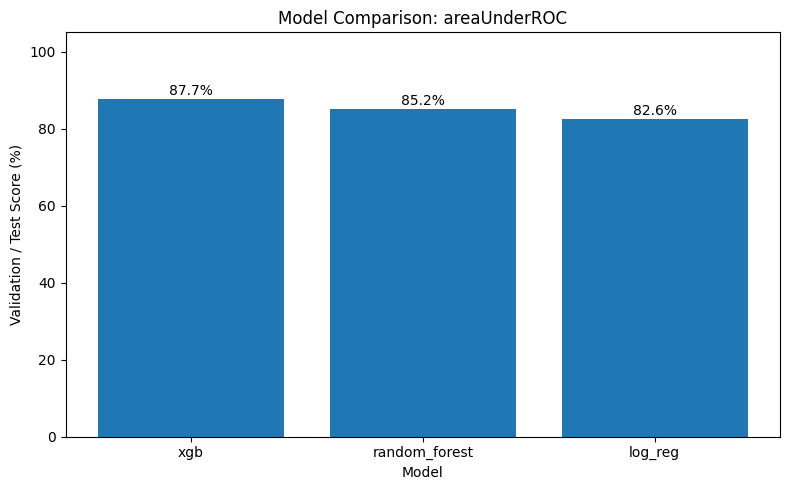

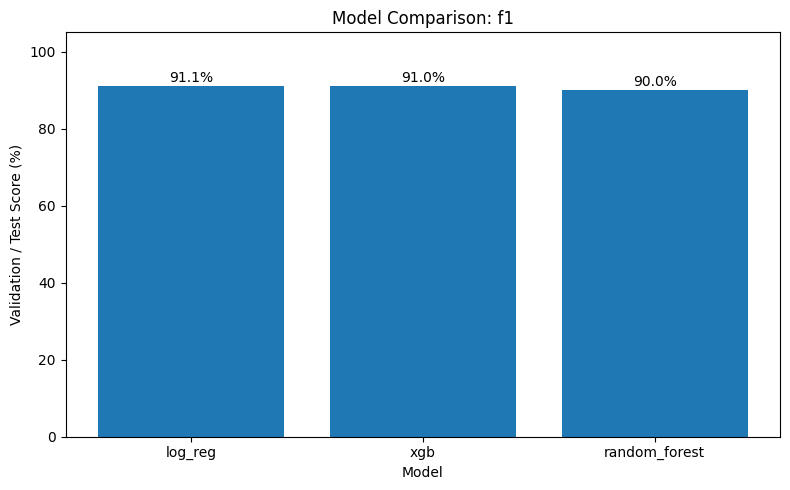

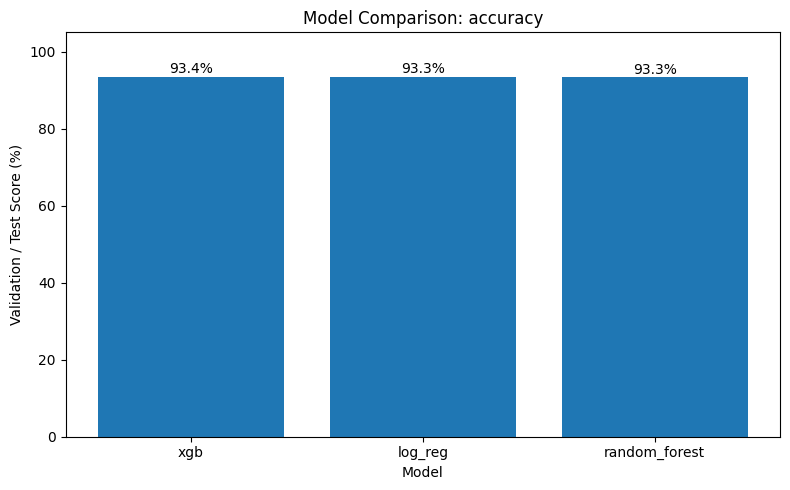

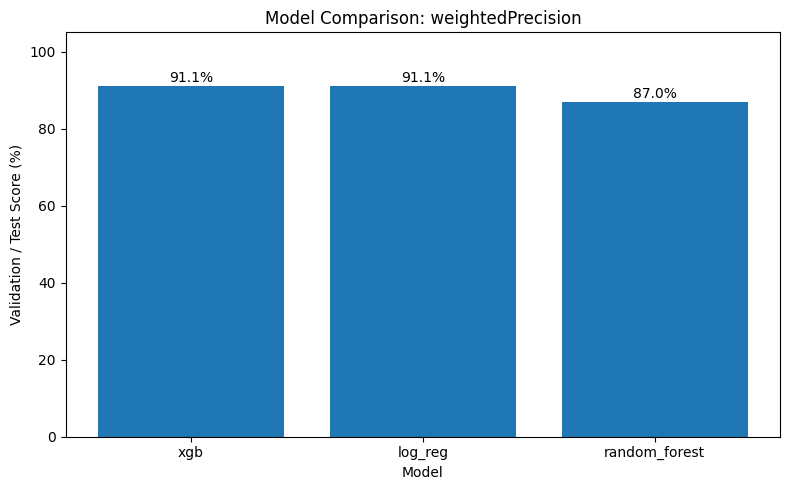

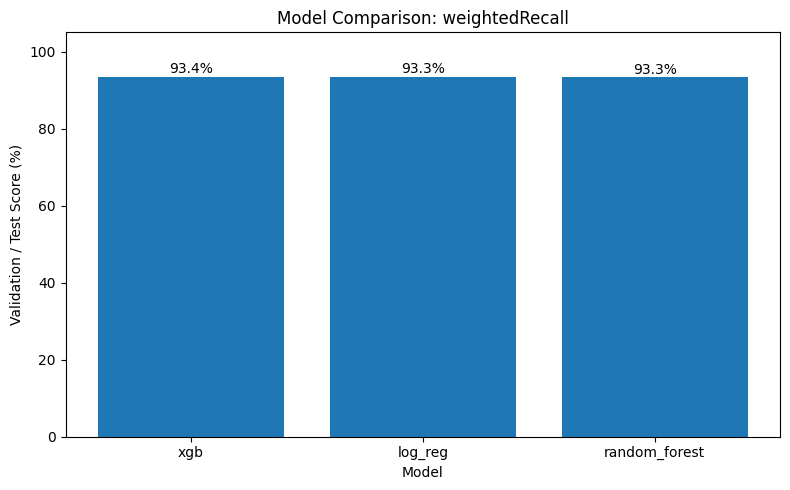

In [ ]:
import matplotlib.pyplot as plt

metrics_to_plot = ["areaUnderROC", "f1", "accuracy", "weightedPrecision", "weightedRecall"]

plot_df = metrics_df[
    (metrics_df["metric"].isin(metrics_to_plot))
].copy()

plot_df["test_percent"] = plot_df["test"] * 100

for metric in metrics_to_plot:
    temp = plot_df[plot_df["metric"] == metric].sort_values("test_percent", ascending=False)

    plt.figure(figsize=(8, 5))
    plt.bar(temp["model"], temp["test_percent"])
    plt.ylabel("Validation / Test Score (%)")
    plt.xlabel("Model")
    plt.title(f"Model Comparison: {metric}")
    plt.ylim(0, 105)

    for i, v in enumerate(temp["test_percent"]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")

    plt.tight_layout()
    plt.show()

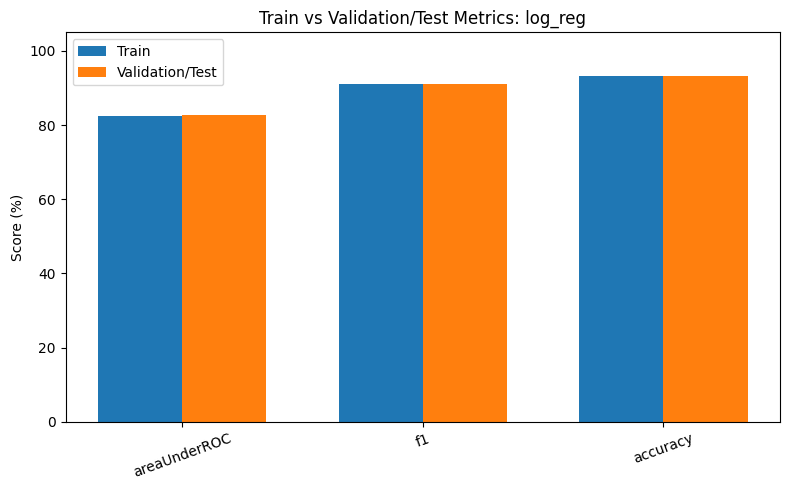

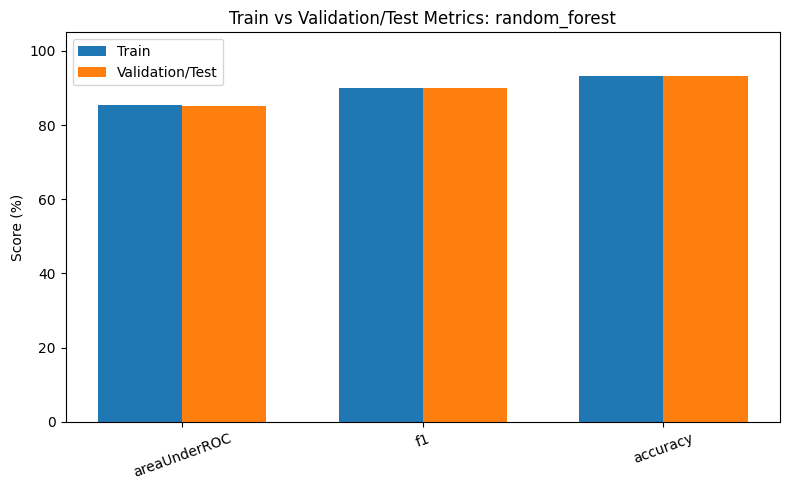

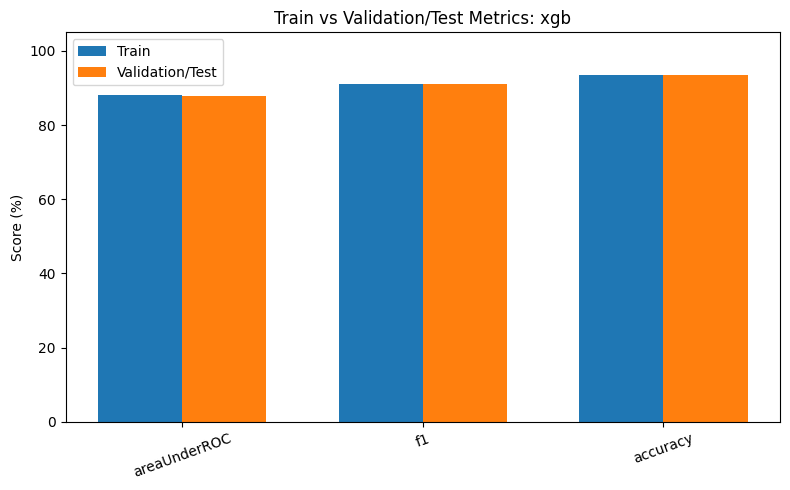

In [ ]:
gap_plot_df = metrics_df[
    metrics_df["metric"].isin(["areaUnderROC", "accuracy", "f1"])
].copy()

gap_plot_df["train_percent"] = gap_plot_df["train"] * 100
gap_plot_df["test_percent"] = gap_plot_df["test"] * 100

for model_name in gap_plot_df["model"].unique():
    temp = gap_plot_df[gap_plot_df["model"] == model_name]

    x = range(len(temp))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar([i - width/2 for i in x], temp["train_percent"], width=width, label="Train")
    plt.bar([i + width/2 for i in x], temp["test_percent"], width=width, label="Validation/Test")

    plt.xticks(x, temp["metric"], rotation=20)
    plt.ylabel("Score (%)")
    plt.title(f"Train vs Validation/Test Metrics: {model_name}")
    plt.ylim(0, 105)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
spark.stop()